In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_percentage_error

Analisi sulla generazione di elettricità

                Value
Date                 
2001-01-01  331770.42
2001-02-01  282305.52
2001-03-01  300016.76
2001-04-01  277521.79
2001-05-01  299747.31


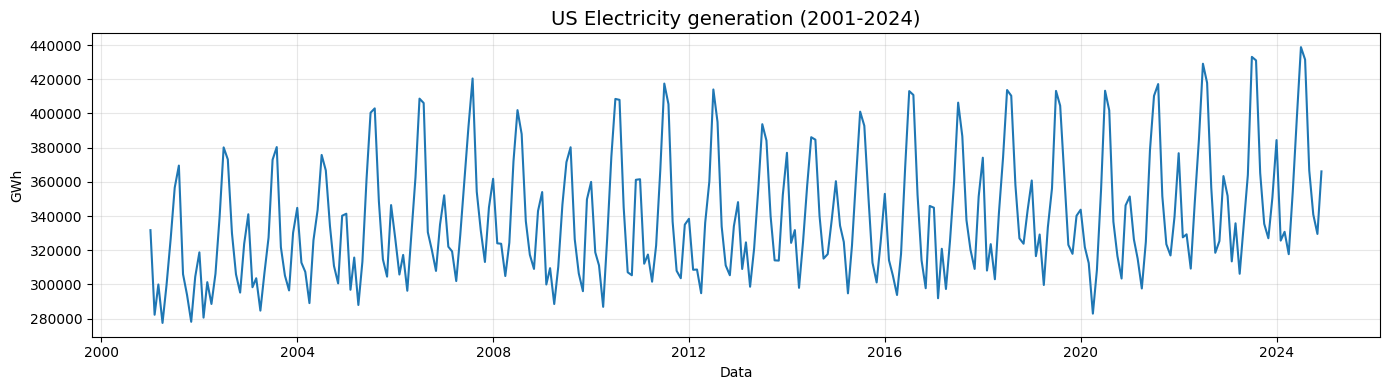

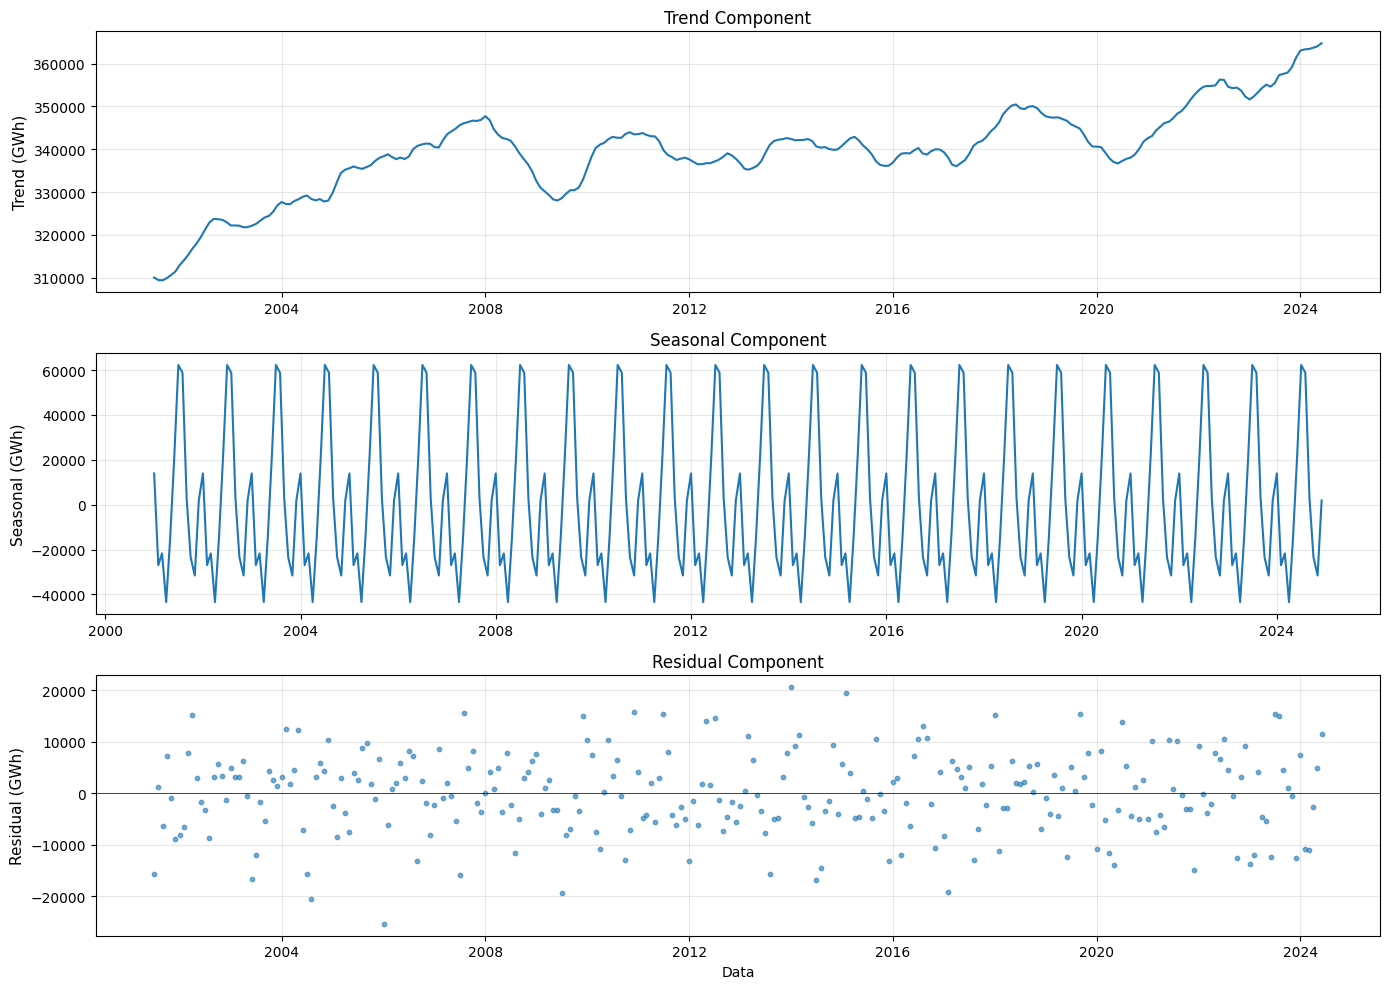

In [45]:
df = pd.read_csv("../data/raw/us_monthly_electricity.csv")
df['Date'] = pd.to_datetime(df['Date'])

mask = (
    (df['State'] == 'US Total') & 
    (df['Category'] == 'Electricity generation') &
    (df['Variable'] == 'Total Generation') &
    (df['Unit'] == 'GWh')
)

ts_data = df.loc[mask, ['Date', 'Value']].sort_values('Date').set_index('Date')
ts_data = ts_data[ts_data.index.year <= 2024]
ts_data = ts_data.asfreq('MS') 

decomposition = seasonal_decompose(ts_data['Value'], model='additive')
print(ts_data.head())

# Grafico 1: Serie originale
plt.figure(figsize=(14, 4))
plt.plot(ts_data.index, ts_data['Value'], linewidth=1.5)
plt.title('US Electricity generation (2001-2024)', fontsize=14)
plt.xlabel('Data')
plt.ylabel('GWh')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# Trend
axes[0].plot(decomposition.trend, linewidth=1.5)
axes[0].set_ylabel('Trend (GWh)', fontsize=11)
axes[0].set_title('Trend Component', fontsize=12)
axes[0].grid(True, alpha=0.3)

# Seasonal
axes[1].plot(decomposition.seasonal, linewidth=1.5)
axes[1].set_ylabel('Seasonal (GWh)', fontsize=11)
axes[1].set_title('Seasonal Component', fontsize=12)
axes[1].grid(True, alpha=0.3)

# Residual (con scatter plot)
axes[2].scatter(decomposition.resid.index, decomposition.resid, s=10, alpha=0.6)
axes[2].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
axes[2].set_ylabel('Residual (GWh)', fontsize=11)
axes[2].set_xlabel('Data')
axes[2].set_title('Residual Component', fontsize=12)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


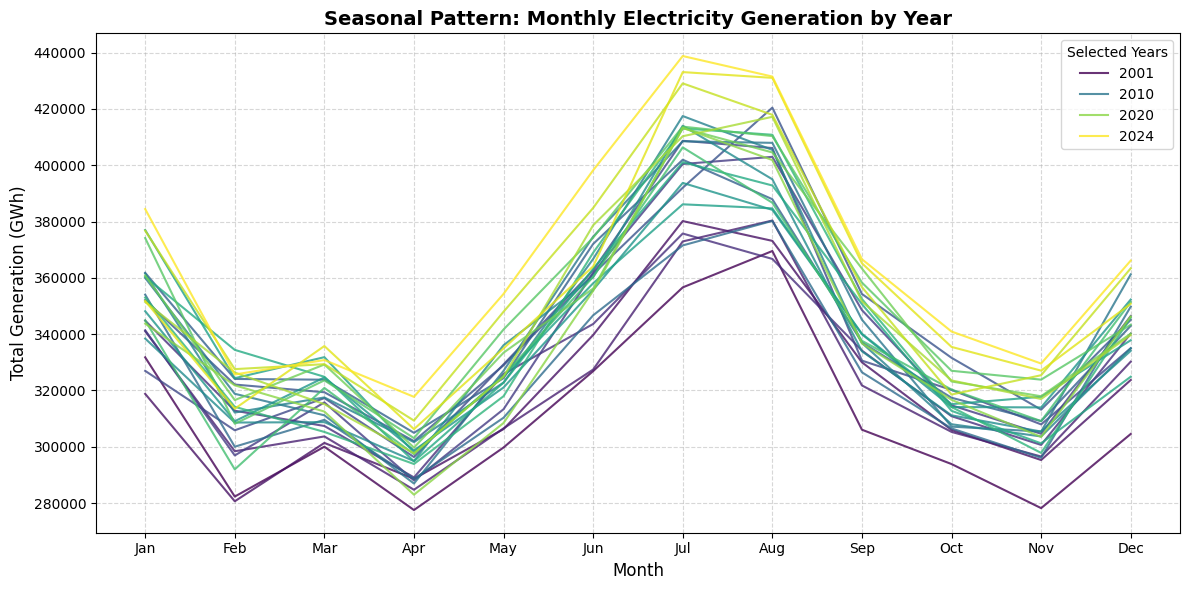

In [61]:
plt.figure(figsize=(12, 6))

ts_data['Year'] = ts_data.index.year
ts_data['Month'] = ts_data.index.month

pivot_df = ts_data.pivot(index='Month', columns='Year', values='Value')

colors = plt.cm.viridis(np.linspace(0, 1, len(pivot_df.columns)))
for i, year in enumerate(pivot_df.columns):
    label = year if year in [2001, 2010, 2020, 2024] else ""
    plt.plot(pivot_df.index, pivot_df[year], color=colors[i], marker='', linewidth=1.5, alpha=0.8, label=label)

plt.title('Seasonal Pattern: Monthly Electricity Generation by Year', fontsize=14, fontweight='bold')
plt.ylabel('Total Generation (GWh)', fontsize=12)
plt.xlabel('Month', fontsize=12)
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.legend(title='Selected Years', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

ts_data = ts_data.drop(columns=['Year', 'Month'])



--- Augmented Dickey-Fuller Test Results ---
ADF Statistic: -2.1335757884715347
p-value: 0.23122962883667625
Critical Values:
	1%: -3.45453261164607
	5%: -2.8721859575020017
	10%: -2.572442854861866
Result: The series is Non-Stationary (Fail to reject Null Hypothesis). Differencing is likely needed.


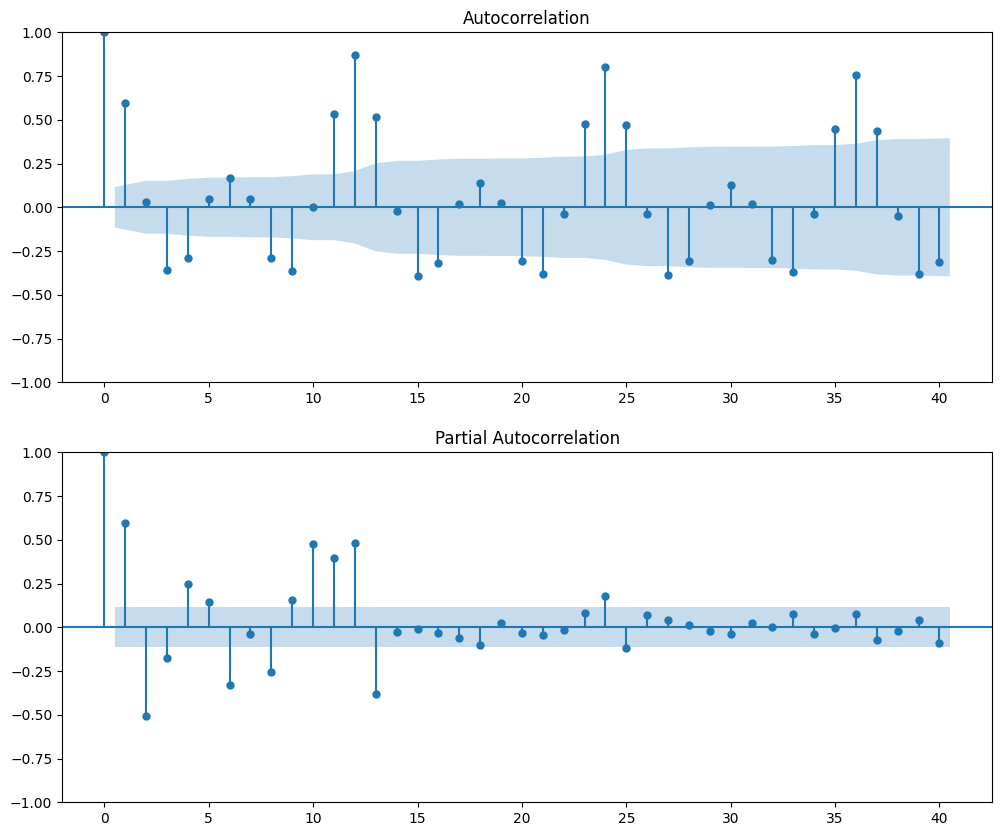

In [25]:
print("\n--- Augmented Dickey-Fuller Test Results ---")
result = adfuller(ts_data['Value'].dropna())
print(f'ADF Statistic: {result[0]}')
print(f'p-value: {result[1]}')
print('Critical Values:')
for key, value in result[4].items():
    print(f'\t{key}: {value}')

if result[1] <= 0.05:
    print("Result: The series is Stationary (Reject Null Hypothesis)")
else:
    print("Result: The series is Non-Stationary (Fail to reject Null Hypothesis). Differencing is likely needed.")

# 3. ACF and PACF Plots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))
plot_acf(ts_data['Value'], ax=ax1, lags=40);
plot_pacf(ts_data['Value'], ax=ax2, lags=40);


ADF Statistic: -5.122649669529774
p-value: 1.2620984597081788e-05
Critical Values:
	1%: -3.4554613060274972
	5%: -2.8725931472675046
	10%: -2.5726600403359887
Result: The series is Stationary (Reject Null Hypothesis)


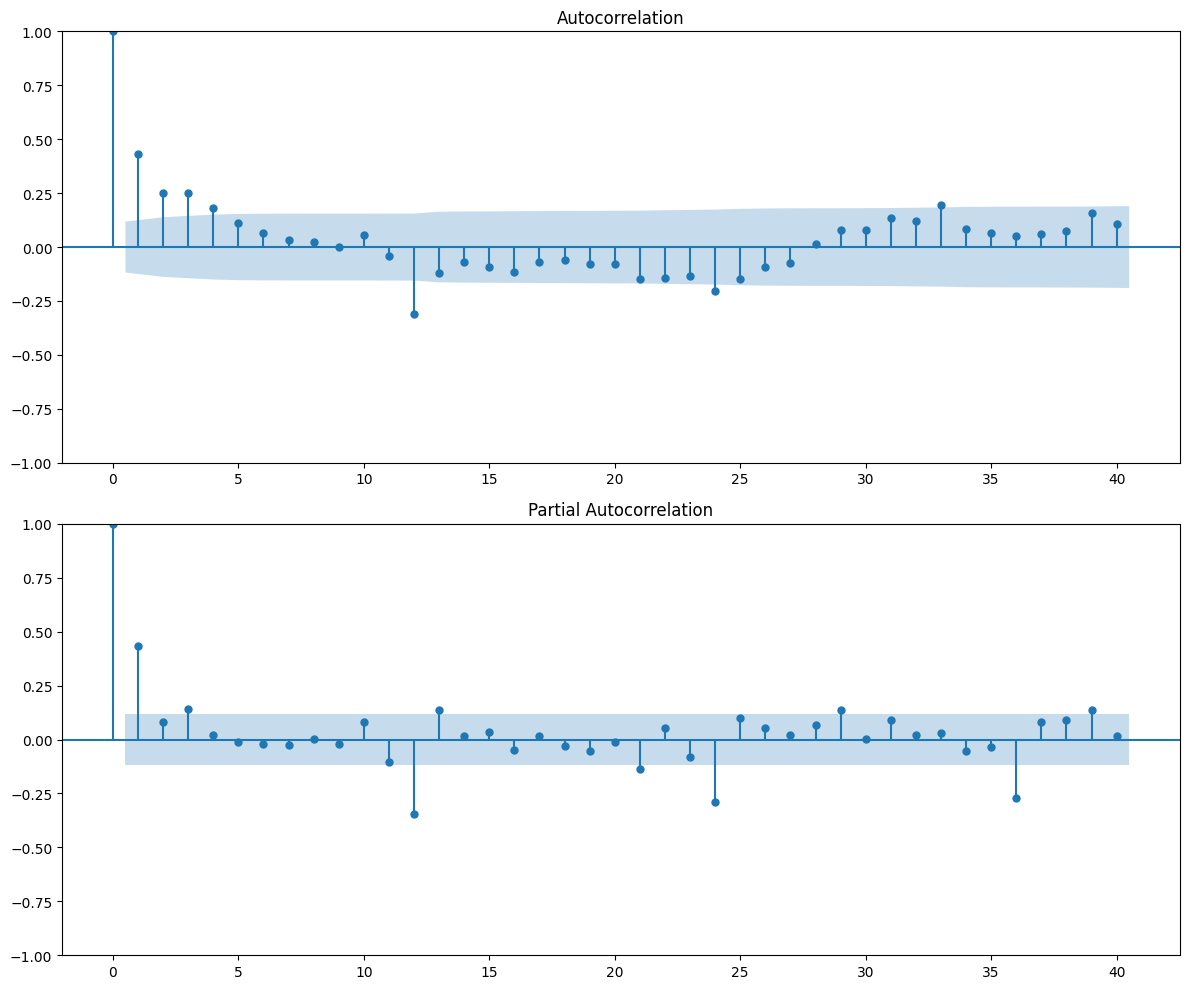

               Value  Year  Month
Date                             
2002-01-01 -12974.00  2002      1
2002-02-01  -1679.02  2002      2
2002-03-01   1344.63  2002      3
2002-04-01  11101.43  2002      4
2002-05-01   6529.59  2002      5


In [26]:
ts_seasonal_diff = ts_data.copy()
ts_seasonal_diff['Value'] = ts_data['Value'].diff(12)
ts_seasonal_diff = ts_seasonal_diff.dropna()

# Ora puoi accedere con ts_seasonal_diff['Value']
adf_test_final = adfuller(ts_seasonal_diff['Value'])
print(f'ADF Statistic: {adf_test_final[0]}')
print(f'p-value: {adf_test_final[1]}')
print('Critical Values:')
for key, value in adf_test_final[4].items():
    print(f'\t{key}: {value}')

if adf_test_final[1] <= 0.05:
    print("Result: The series is Stationary (Reject Null Hypothesis)")
else:
    print("Result: The series is Non-Stationary (Fail to reject Null Hypothesis). Differencing is likely needed.")

# ACF and PACF Plots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))
plot_acf(ts_seasonal_diff['Value'], ax=ax1, lags=40)
plot_pacf(ts_seasonal_diff['Value'], ax=ax2, lags=40)
plt.tight_layout()
plt.show()

print(ts_seasonal_diff.head())

Training data: dal 2001-01-01 al 2022-12-01
Test data: dal 2023-01-01 al 2024-12-01
Addestramento del modello in corso...
Modello addestrato!
                                     SARIMAX Results                                      
Dep. Variable:                              Value   No. Observations:                  264
Model:             SARIMAX(1, 0, 0)x(1, 1, 0, 12)   Log Likelihood               -2558.112
Date:                            Sun, 14 Dec 2025   AIC                           5122.223
Time:                                    11:42:37   BIC                           5132.653
Sample:                                01-01-2001   HQIC                          5126.426
                                     - 12-01-2022                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------

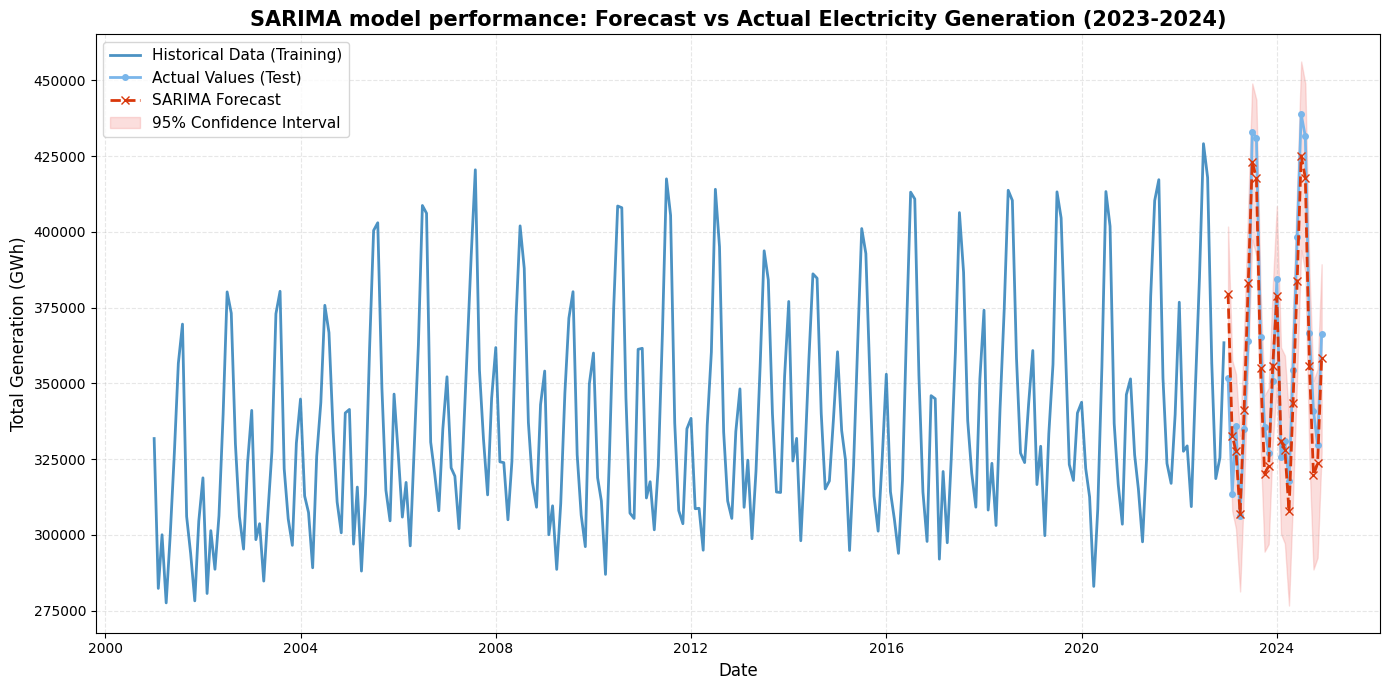

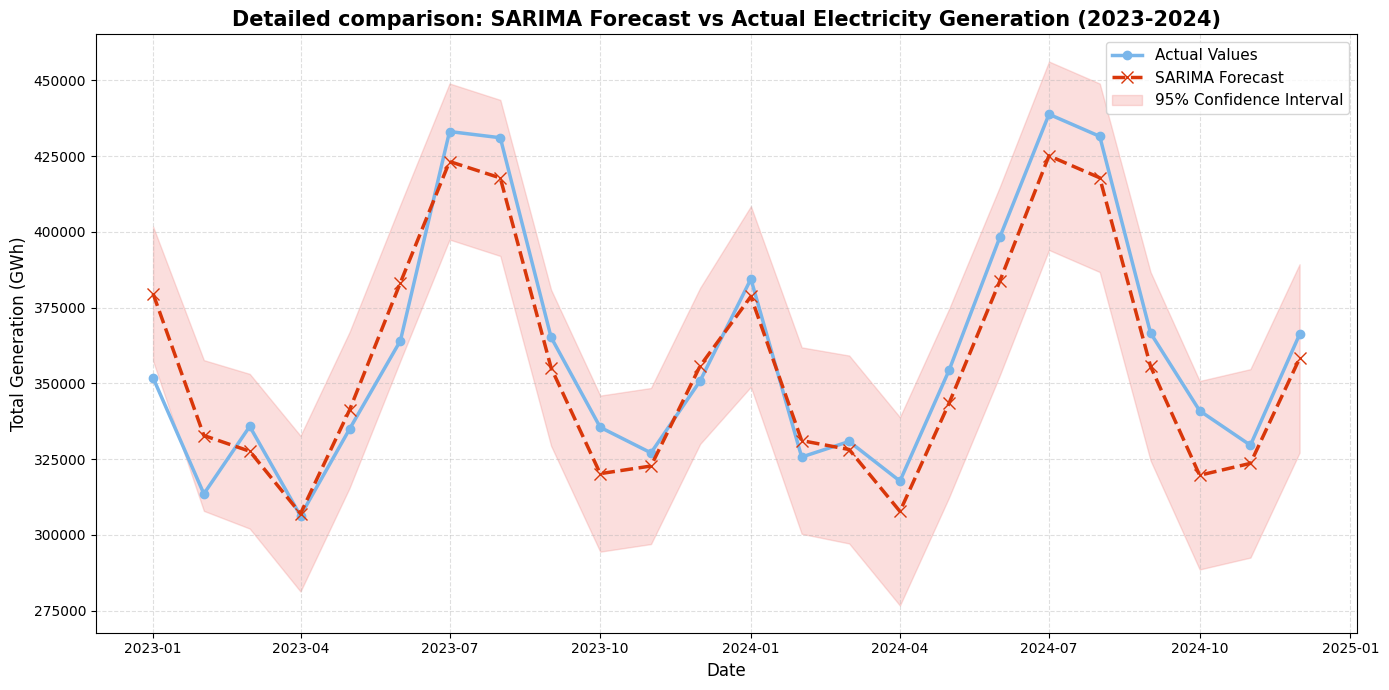


Errore Medio Assoluto Percentuale (MAPE): 3.02%
Significa che il modello sbaglia in media del 3.02%


In [57]:
train_data = ts_data.iloc[:-24]
test_data = ts_data.iloc[-24:]

print(f"Training data: dal {train_data.index.min().date()} al {train_data.index.max().date()}")
print(f"Test data: dal {test_data.index.min().date()} al {test_data.index.max().date()}")

my_order = (1, 0, 0)              # (p, d, q) - Parte non stagionale
my_seasonal_order = (1, 1, 0, 12) # (P, D, Q, m) - Parte stagionale (m=12 mesi)

model = SARIMAX(train_data['Value'], 
                order=my_order, 
                seasonal_order=my_seasonal_order,
                enforce_stationarity=False,
                enforce_invertibility=False)


print("Addestramento del modello in corso...")
model_fit = model.fit(disp=False)
print("Modello addestrato!")
print(model_fit.summary())

forecast = model_fit.get_forecast(steps=len(test_data))
predicted_values = forecast.predicted_mean
conf_int = forecast.conf_int()

plt.figure(figsize=(14, 7))

# Dati di training - blu pastello
plt.plot(train_data.index, train_data['Value'], 
         label='Historical Data (Training)', linewidth=2.0, alpha=0.8) 

# Dati reali test - verde chiaro/teal
plt.plot(test_data.index, test_data['Value'], 
         label='Actual Values (Test)', 
         color="#7AB6EA", linewidth=2.0, marker='o', markersize=4)  # Azzurro/Teal

# Previsioni - arancione/corallo
plt.plot(test_data.index, predicted_values, 
         label='SARIMA Forecast', 
         color="#D9370A", linestyle='--', linewidth=2.0, marker='x', markersize=6)  # Arancione

# Intervallo di confidenza - arancione chiaro
plt.fill_between(test_data.index, 
                 conf_int.iloc[:, 0], 
                 conf_int.iloc[:, 1], 
                 color="#F17C78", alpha=0.25, 
                 label='95% Confidence Interval')  # Arancione chiaro

plt.title('SARIMA model performance: Forecast vs Actual Electricity Generation (2023-2024)', 
          fontsize=15, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Total Generation (GWh)', fontsize=12)
plt.legend(loc='best', fontsize=11)
plt.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

#Grafico 2: Comparazione dettagliata

plt.figure(figsize=(14, 7))

# Valori reali - azzurro teal
plt.plot(test_data.index, test_data['Value'], 
         label='Actual Values', 
         color="#7AB6EA", linewidth=2.5, marker='o', markersize=6)

# Previsioni - rosso/arancione
plt.plot(test_data.index, predicted_values, 
         label='SARIMA Forecast', 
         color="#D9370A", linestyle='--', linewidth=2.5, marker='x', markersize=8)

# Intervallo di confidenza - rosa/corallo
plt.fill_between(test_data.index, 
                 conf_int.iloc[:, 0], 
                 conf_int.iloc[:, 1], 
                 color="#F17C78", alpha=0.25, 
                 label='95% Confidence Interval')

plt.title('Detailed comparison: SARIMA Forecast vs Actual Electricity Generation (2023-2024)', 
          fontsize=15, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Total Generation (GWh)', fontsize=12)
plt.legend(fontsize=11, loc='best')
plt.grid(True, alpha=0.4, linestyle='--')
plt.tight_layout()
plt.show()

mape = mean_absolute_percentage_error(test_data['Value'], predicted_values)
print(f"\nErrore Medio Assoluto Percentuale (MAPE): {mape:.2%}")
print(f"Significa che il modello sbaglia in media del {mape:.2%}")

Si riaddestra usando tutti i dati stavolta

Training model on full dataset...
Model trained successfully!

=== Future Forecasts ===
            Predicted_Value    Lower_Bound    Upper_Bound
Date                                                     
2025-01-01    377133.473028  354196.706943  400070.239113
2025-02-01    323572.236378  298000.351299  349144.121457
2025-03-01    333971.262709  307799.152013  360143.373405
2025-04-01    313960.401514  287644.520382  340276.282647
2025-05-01    347201.524796  320850.830017  373552.219576
2025-06-01    385301.958034  358942.811479  411661.104589
2025-07-01    436704.387101  410343.187415  463065.586786
2025-08-01    431380.301176  405018.602663  457741.999689
2025-09-01    366092.904947  339731.085235  392454.724660
2025-10-01    338852.730976  312490.881816  365214.580136
2025-11-01    328602.354659  302240.498343  354964.210974
2025-12-01    360268.930087  333907.072033  386630.788140
2026-01-01    379935.066276  350011.770526  409858.362026
2026-02-01    324376.079608  293649.727575

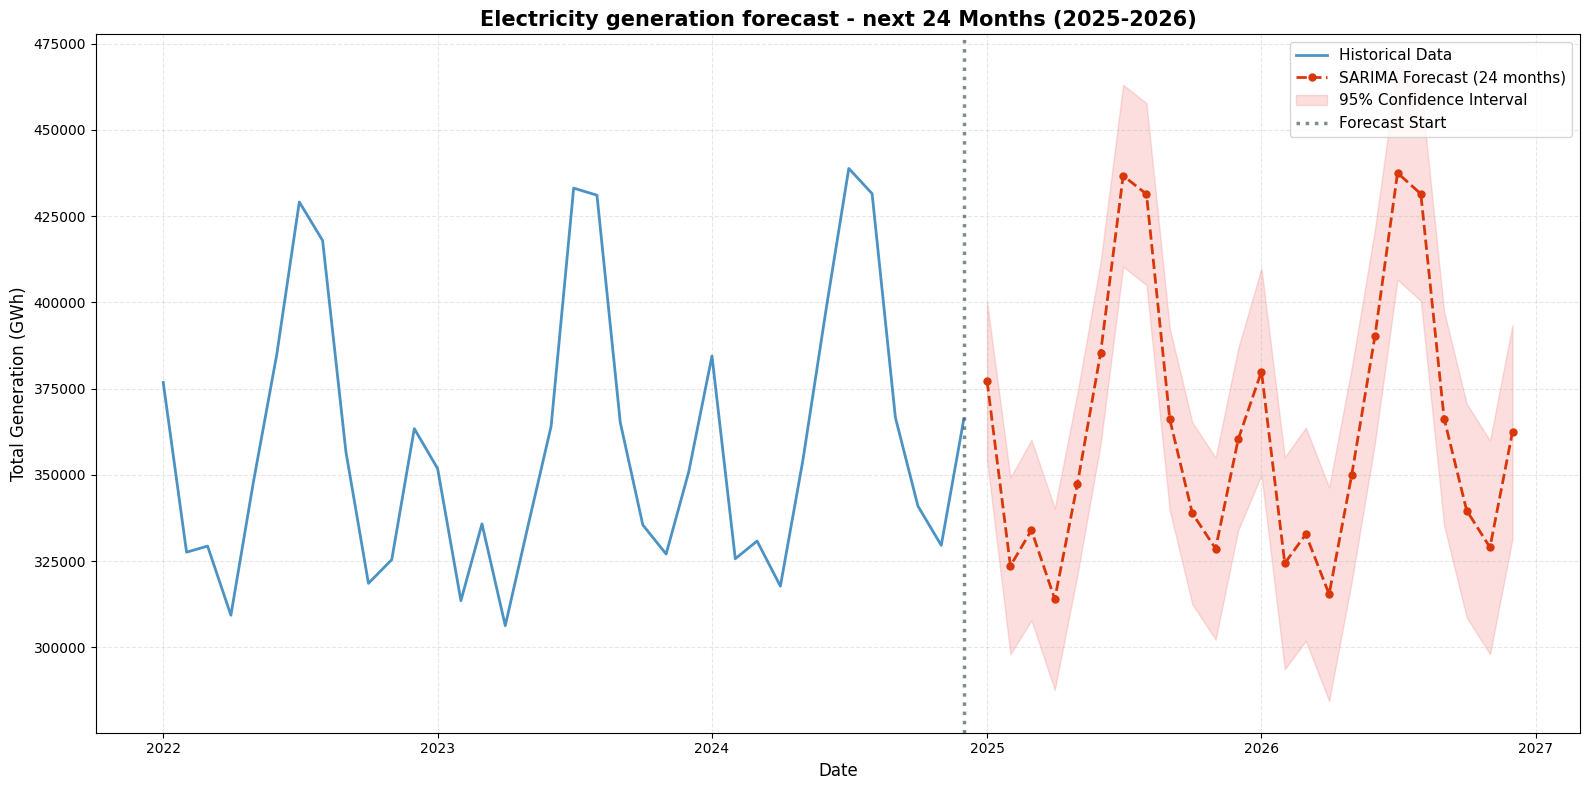

In [ ]:
full_data = ts_data['Value']

my_order = (1, 0, 0)
my_seasonal_order = (1, 1, 0, 12)

model_full = SARIMAX(full_data, 
                     order=my_order, 
                     seasonal_order=my_seasonal_order,
                     enforce_stationarity=False,
                     enforce_invertibility=False)

print("Training model on full dataset...")
model_full_fit = model_full.fit(disp=False)
print("Model trained successfully!")

n_months = 24  # Modify to forecast more or fewer months

forecast_future = model_full_fit.get_forecast(steps=n_months)
predicted_future = forecast_future.predicted_mean
conf_int_future = forecast_future.conf_int()

last_date = ts_data.index[-1]
future_dates = pd.date_range(start=last_date + pd.DateOffset(months=1), 
                             periods=n_months, 
                             freq='MS') 

forecast_df = pd.DataFrame({
    'Date': future_dates,
    'Predicted_Value': predicted_future.values,
    'Lower_Bound': conf_int_future.iloc[:, 0].values,
    'Upper_Bound': conf_int_future.iloc[:, 1].values
})
forecast_df.set_index('Date', inplace=True)

print("\n=== Future Forecasts ===")
print(forecast_df)

plt.figure(figsize=(16, 8))

historical = ts_data.iloc[-36:]
plt.plot(historical.index, historical['Value'], 
         label='Historical Data', linewidth=2.0, alpha=0.8)

plt.plot(future_dates, predicted_future, 
         label=f'SARIMA Forecast ({n_months} months)', 
         color="#D9370A", linestyle='--', linewidth=2.0, marker='o', markersize=5)

plt.fill_between(future_dates, 
                 conf_int_future.iloc[:, 0], 
                 conf_int_future.iloc[:, 1], 
                 color="#F17C78", alpha=0.25, 
                 label='95% Confidence Interval')

plt.axvline(x=ts_data.index[-1], color="#4A5866", 
            linestyle=':', linewidth=2.5, label='Forecast Start', alpha=0.7)

plt.title(f'Electricity Generation Forecast - Next {n_months} Months (2025-2026)', 
          fontsize=15, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Total Generation (GWh)', fontsize=12)
plt.legend(loc='best', fontsize=11)
plt.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()


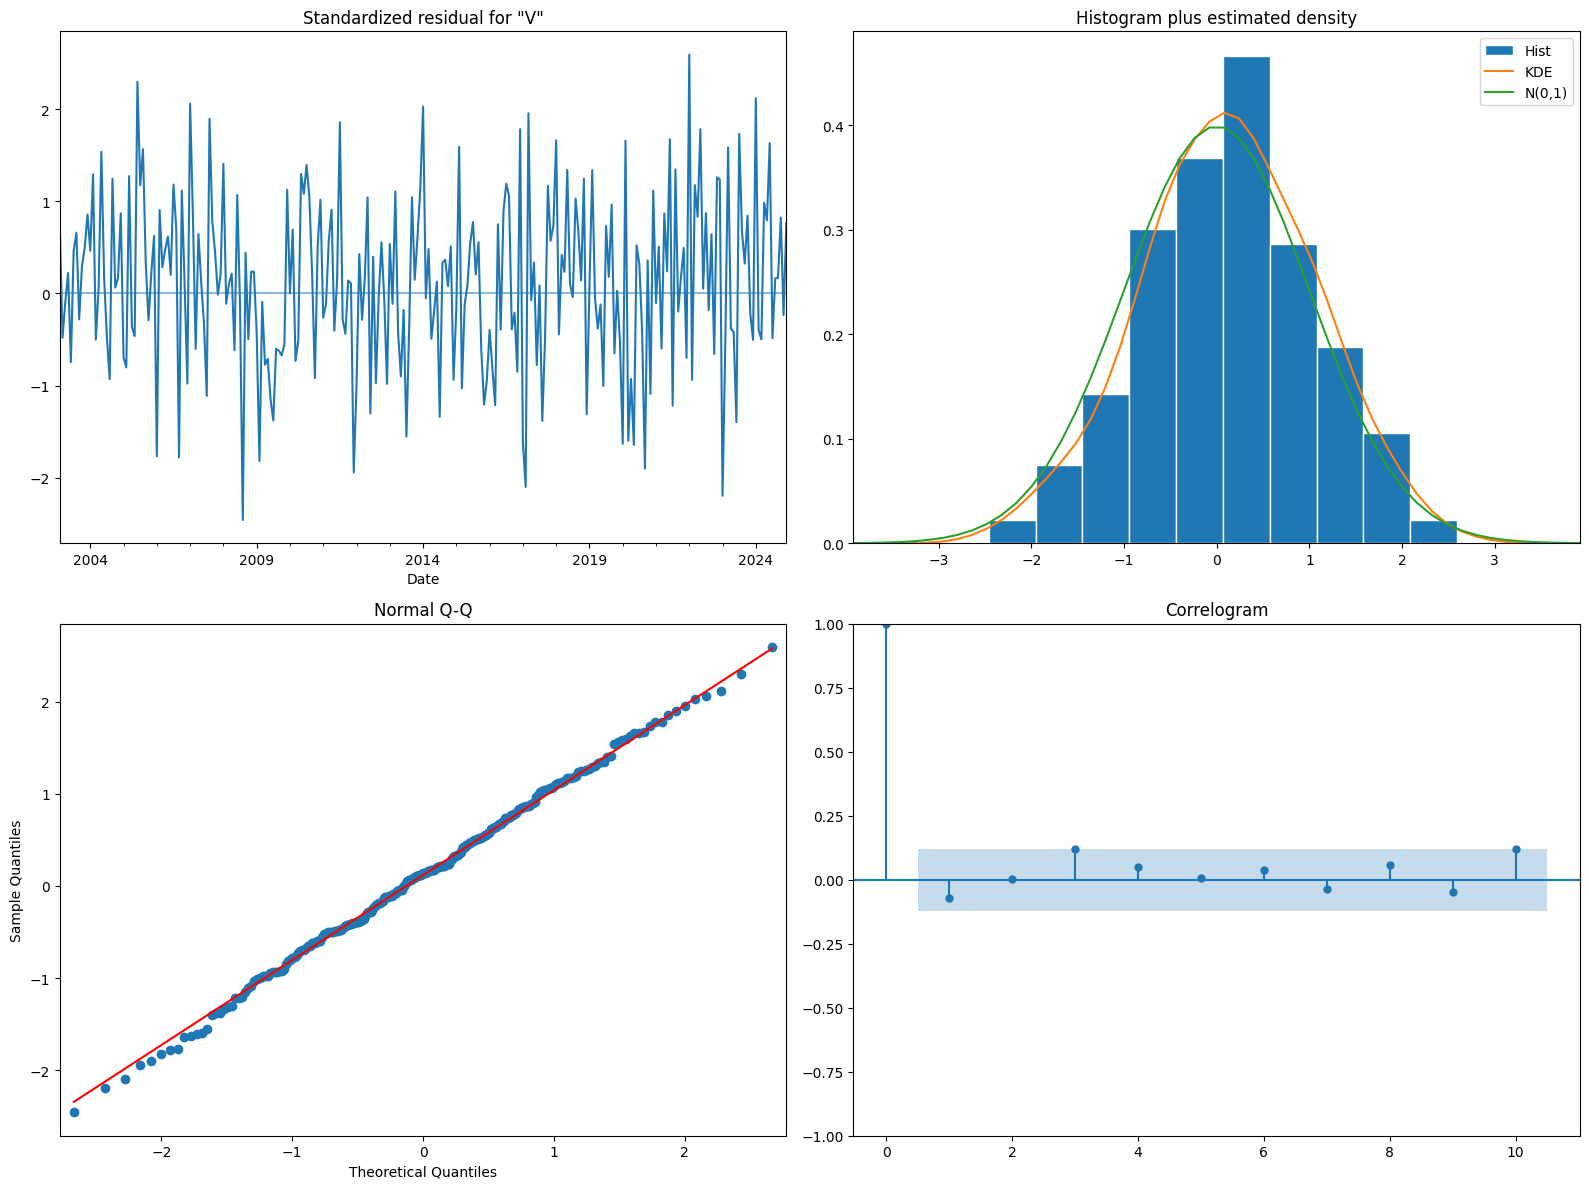

In [29]:
# Diagnostica completa del modello
fig = model_full_fit.plot_diagnostics(figsize=(16, 12))
plt.tight_layout()
plt.show()


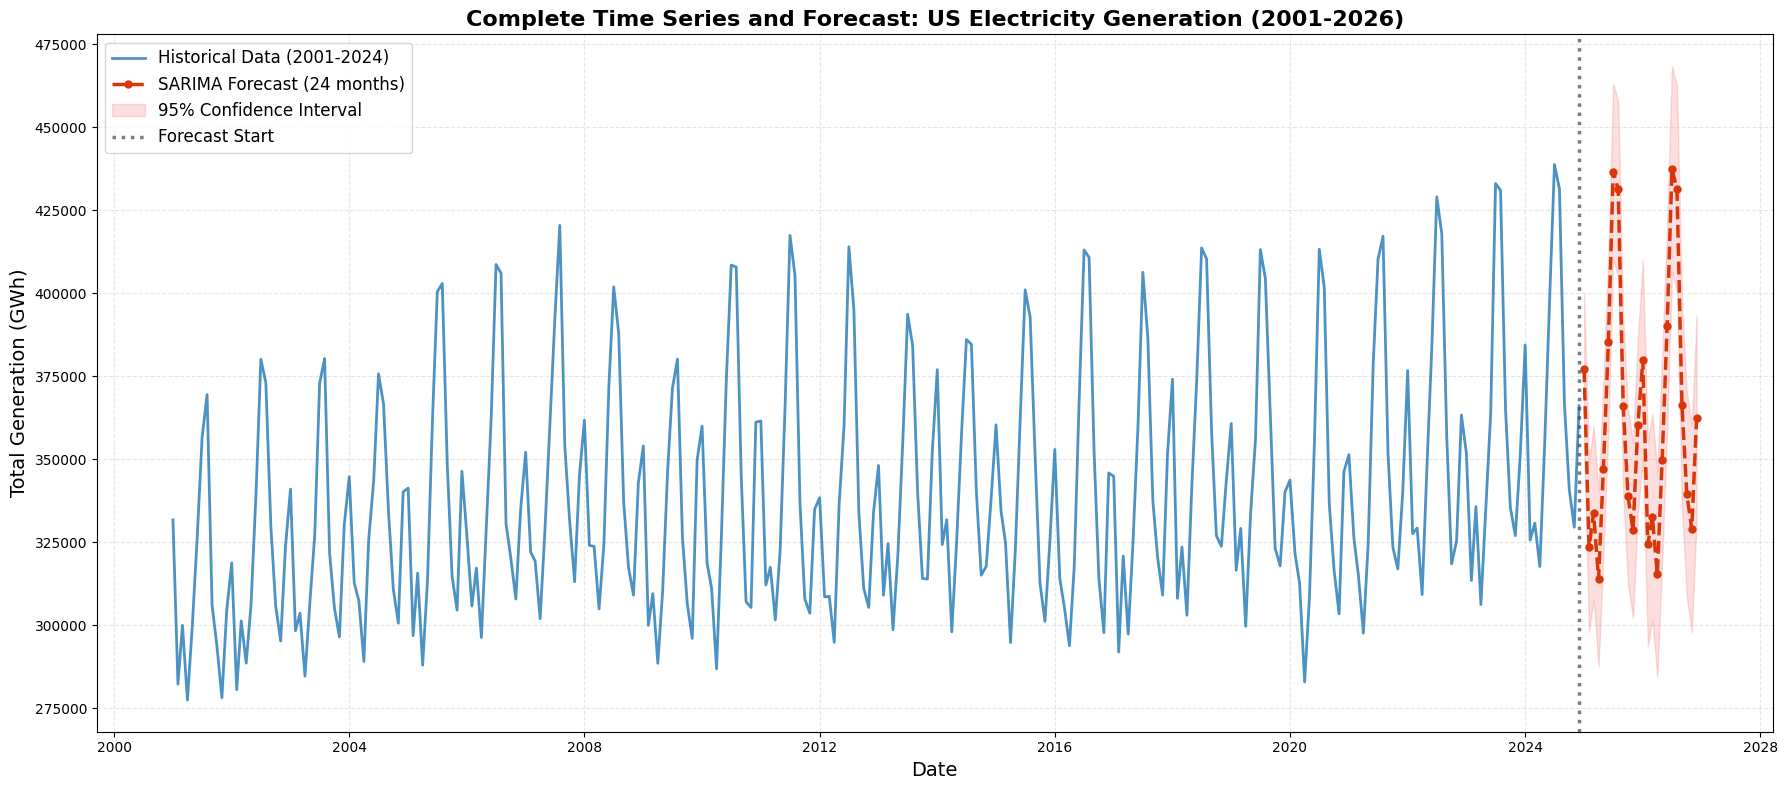

In [ ]:
# Grafico 2: Visualizzazione completa serie storica + previsioni
plt.figure(figsize=(18, 8))

plt.plot(ts_data.index, ts_data['Value'], 
         label='Historical Data (2001-2024)', linewidth=2.0, alpha=0.8)

plt.plot(future_dates, predicted_future, 
         label=f'SARIMA Forecast ({n_months} months)', 
         color="#D9370A", linestyle='--', linewidth=2.5, marker='o', markersize=5)

plt.fill_between(future_dates, 
                 conf_int_future.iloc[:, 0], 
                 conf_int_future.iloc[:, 1], 
                 color="#F17C78", alpha=0.25, label='95% Confidence Interval')

plt.axvline(x=ts_data.index[-1], color='#4A5866', 
            linestyle=':', linewidth=2.5, label='Forecast Start', alpha=0.7)

plt.title('Complete Time Series and Forecast: US Electricity Generation (2001-2026)', 
          fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=14)
plt.ylabel('Total Generation (GWh)', fontsize=14)
plt.legend(fontsize=12, loc='best')
plt.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()


Analisi sulle emissioni totali

                Value
Date                 
2001-01-01  181782.37
2001-02-01  151267.55
2001-03-01  160139.01
2001-04-01  148197.66
2001-05-01  159395.30


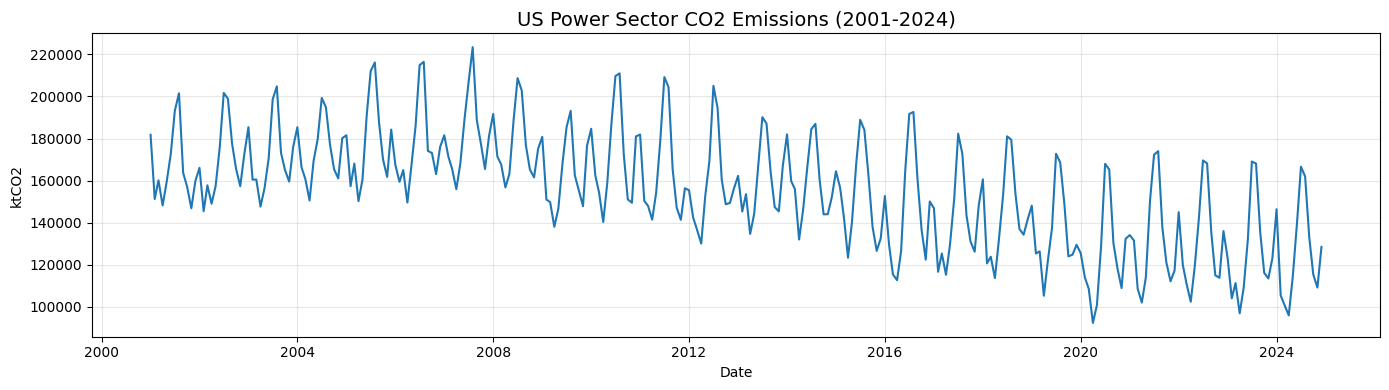

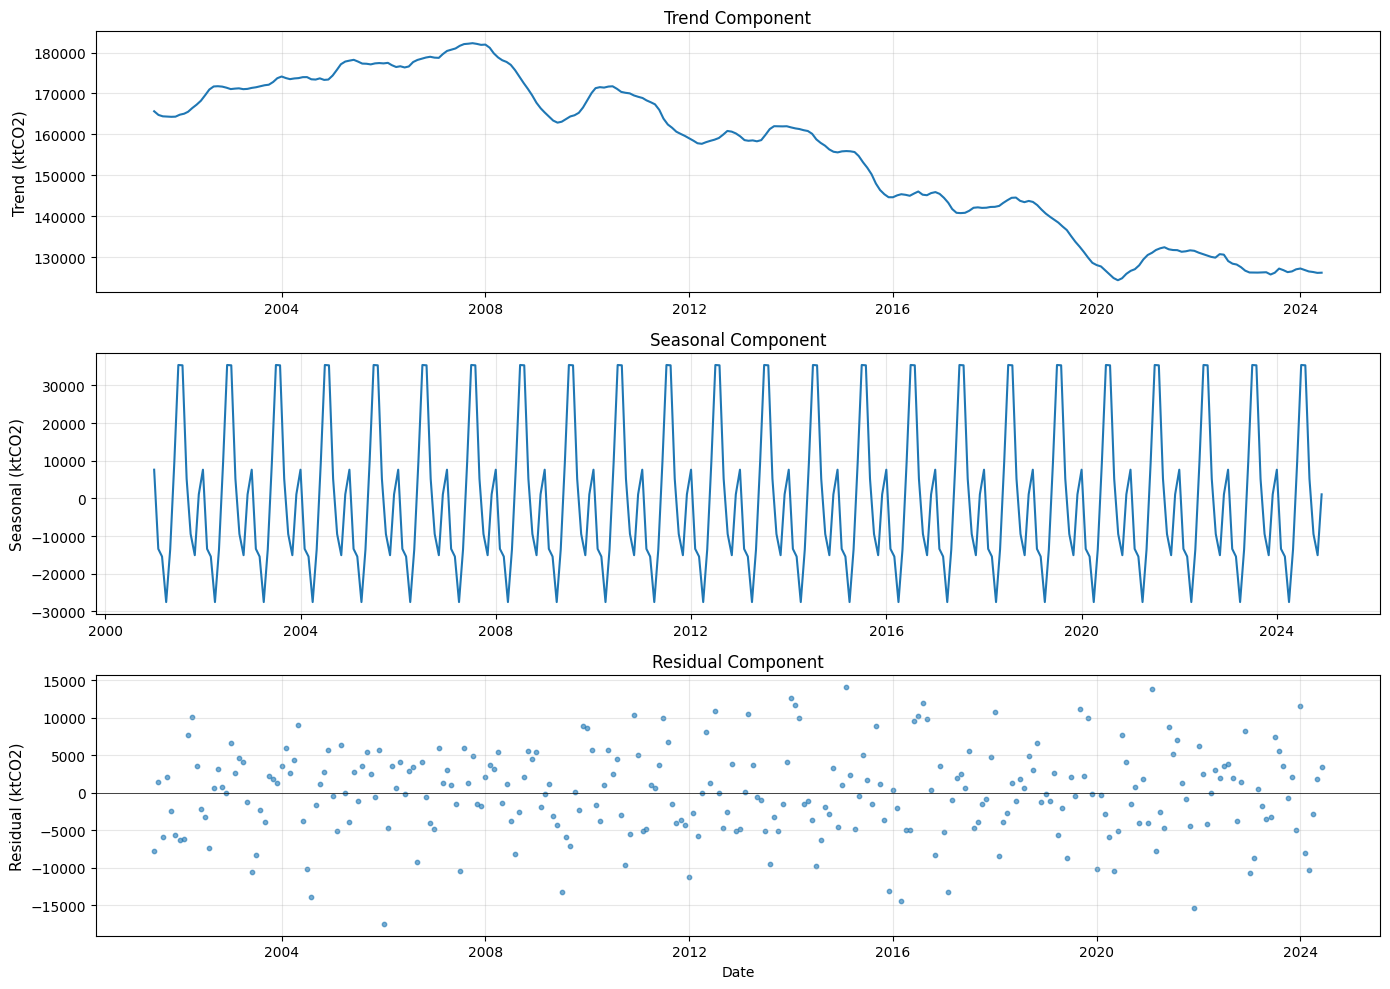

In [62]:
df_emissions = pd.read_csv("../data/raw/us_monthly_electricity.csv")
df_emissions['Date'] = pd.to_datetime(df_emissions['Date'])

mask_emissions = (
    (df_emissions['State'] == 'US Total') & 
    (df_emissions['Category'] == 'Power sector emissions') &
    (df_emissions['Variable'] == 'Total emissions') &
    (df_emissions['Unit'] == 'ktCO2')
)

ts_emissions = df_emissions.loc[mask_emissions, ['Date', 'Value']].sort_values('Date').set_index('Date')
ts_emissions = ts_emissions[ts_emissions.index.year <= 2024]
ts_emissions = ts_emissions.asfreq('MS')

decomposition_emissions = seasonal_decompose(ts_emissions['Value'], model='additive')
print(ts_emissions.head())

# Grafico 1: Serie originale
plt.figure(figsize=(14, 4))
plt.plot(ts_emissions.index, ts_emissions['Value'], linewidth=1.5)
plt.title('US Power Sector CO2 Emissions (2001-2024)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('ktCO2')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Grafico 2: Componenti della decomposizione
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# Trend
axes[0].plot(decomposition_emissions.trend, linewidth=1.5)
axes[0].set_ylabel('Trend (ktCO2)', fontsize=11)
axes[0].set_title('Trend Component', fontsize=12)
axes[0].grid(True, alpha=0.3)

# Seasonal
axes[1].plot(decomposition_emissions.seasonal, linewidth=1.5)
axes[1].set_ylabel('Seasonal (ktCO2)', fontsize=11)
axes[1].set_title('Seasonal Component', fontsize=12)
axes[1].grid(True, alpha=0.3)

# Residual (con scatter plot)
axes[2].scatter(decomposition_emissions.resid.index, decomposition_emissions.resid, s=10, alpha=0.6)
axes[2].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
axes[2].set_ylabel('Residual (ktCO2)', fontsize=11)
axes[2].set_xlabel('Date')
axes[2].set_title('Residual Component', fontsize=12)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


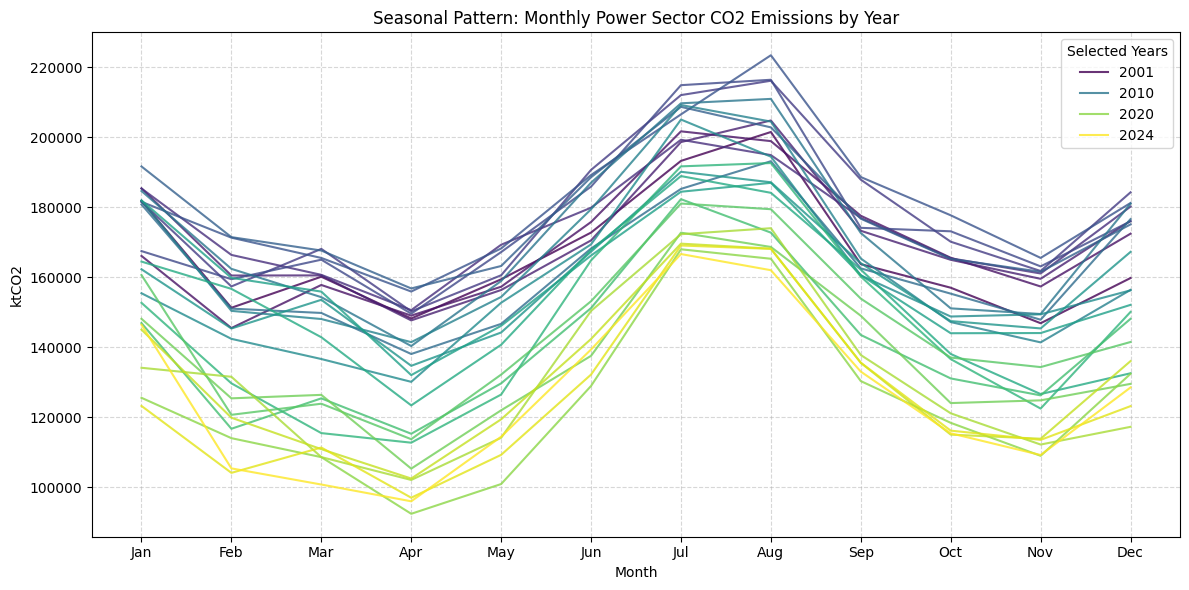

In [63]:
plt.figure(figsize=(12, 6))

ts_emissions['Year'] = ts_emissions.index.year
ts_emissions['Month'] = ts_emissions.index.month

pivot_emissions = ts_emissions.pivot(index='Month', columns='Year', values='Value')

colors = plt.cm.viridis(np.linspace(0, 1, len(pivot_emissions.columns)))
for i, year in enumerate(pivot_emissions.columns):
    label = year if year in [2001, 2010, 2020, 2024] else ""
    plt.plot(pivot_emissions.index, pivot_emissions[year], 
             color=colors[i], marker='', linewidth=1.5, alpha=0.8, label=label)

plt.title('Seasonal Pattern: Monthly Power Sector CO2 Emissions by Year')
plt.ylabel('ktCO2')
plt.xlabel('Month')
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.legend(title='Selected Years')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


--- Augmented Dickey-Fuller Test Results ---
ADF Statistic: -0.152613725275687
p-value: 0.9439392482690963
Critical Values:
	1%: -3.4547128138328875
	5%: -2.8722649771800155
	10%: -2.5724850011573914
Result: The series is Non-Stationary (Fail to reject Null Hypothesis). Differencing is likely needed.


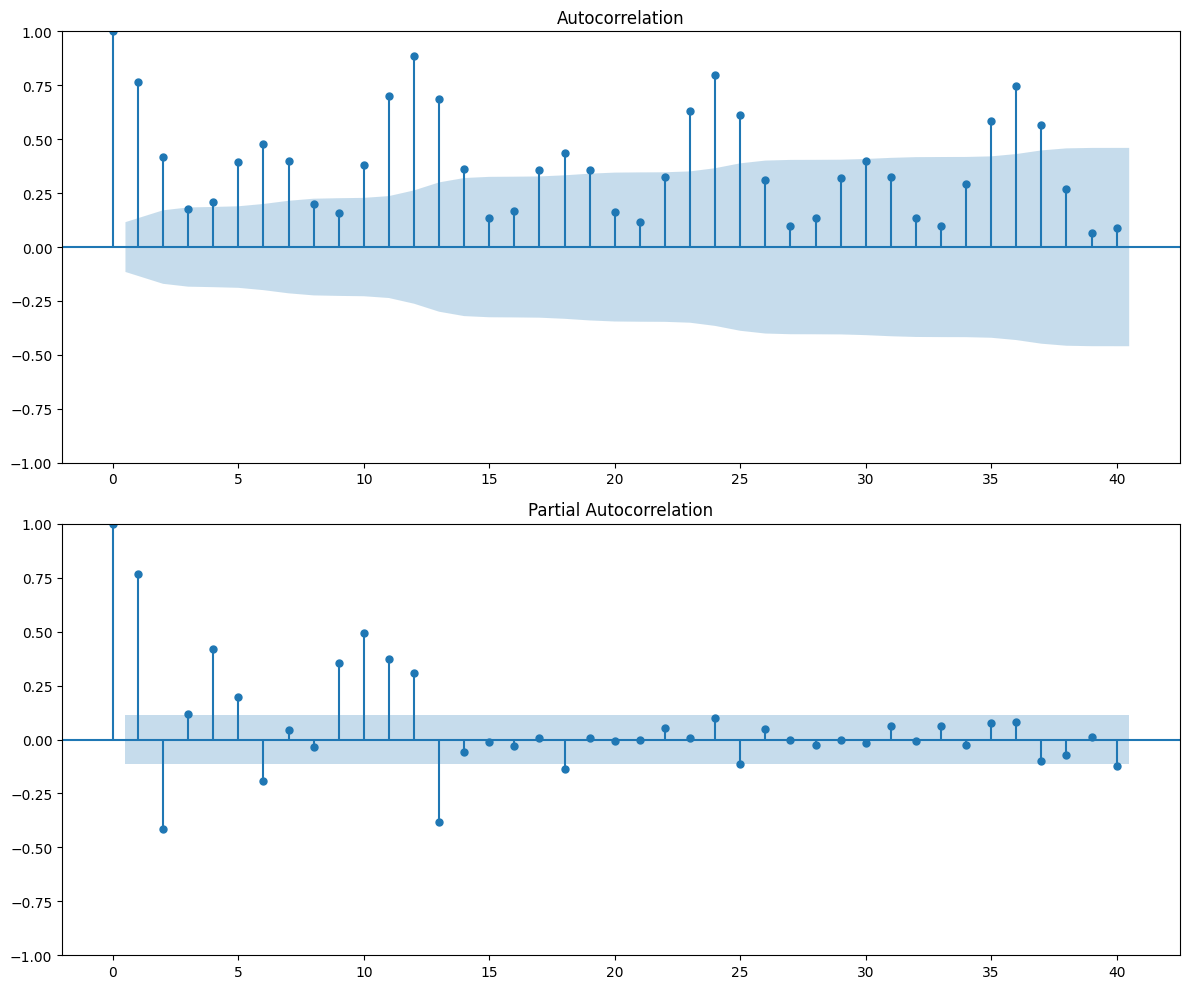

In [64]:
print("\n--- Augmented Dickey-Fuller Test Results ---")
result_emissions = adfuller(ts_emissions['Value'].dropna())
print(f'ADF Statistic: {result_emissions[0]}')
print(f'p-value: {result_emissions[1]}')
print('Critical Values:')
for key, value in result_emissions[4].items():
    print(f'\t{key}: {value}')

if result_emissions[1] <= 0.05:
    print("Result: The series is Stationary (Reject Null Hypothesis)")
else:
    print("Result: The series is Non-Stationary (Fail to reject Null Hypothesis). Differencing is likely needed.")

# ACF and PACF Plots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))
plot_acf(ts_emissions['Value'], ax=ax1, lags=40)
ax1.set_title('Autocorrelation')
plot_pacf(ts_emissions['Value'], ax=ax2, lags=40)
ax2.set_title('Partial Autocorrelation')
plt.tight_layout()
plt.show()

ADF Statistic: -4.722425787475618
p-value: 7.635782607979413e-05
Critical Values:
	1%: -3.4554613060274972
	5%: -2.8725931472675046
	10%: -2.5726600403359887
Result: The series is Stationary (Reject Null Hypothesis)


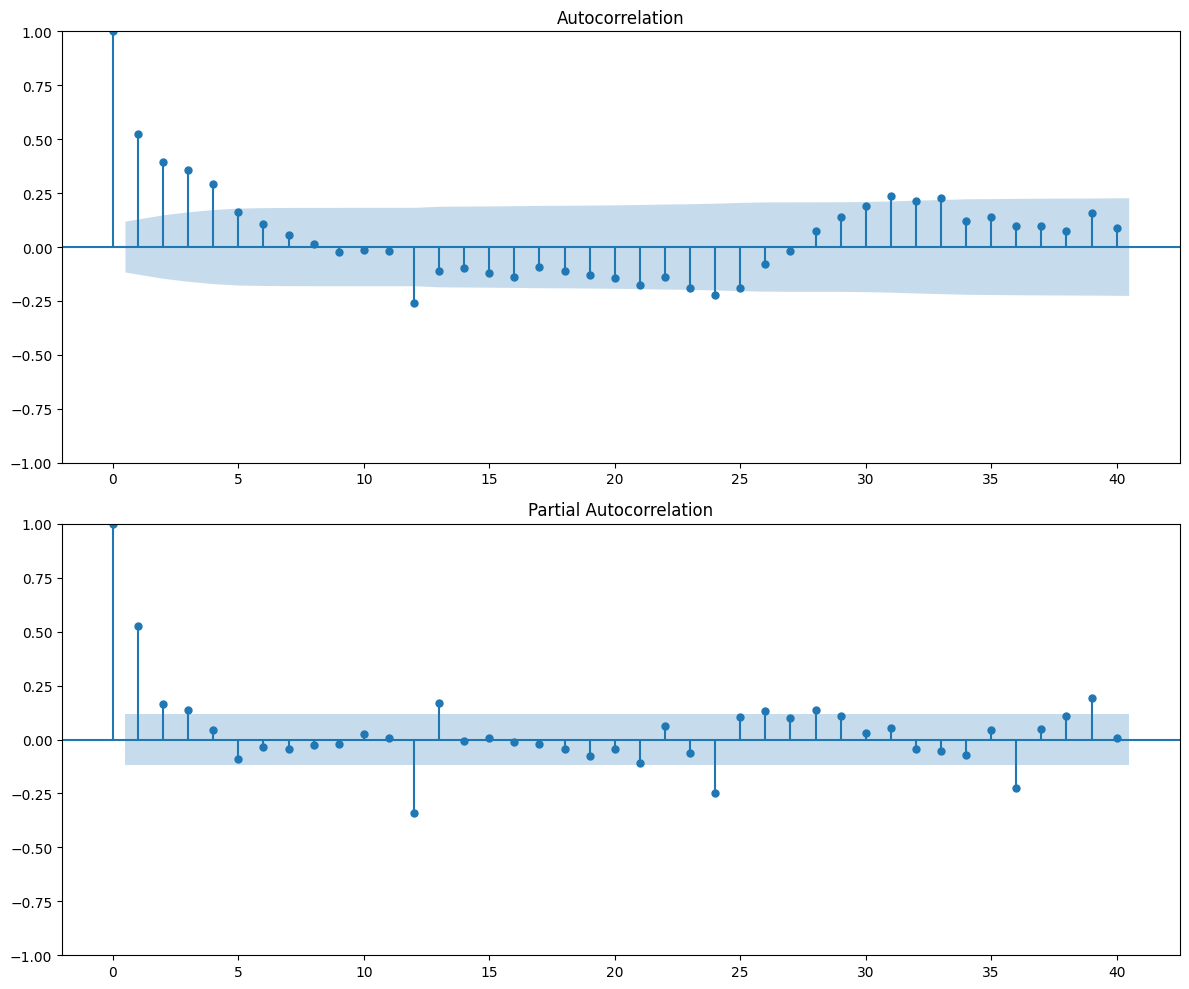

               Value  Year  Month
Date                             
2002-01-01 -15694.37  2002      1
2002-02-01  -5796.67  2002      2
2002-03-01  -2355.98  2002      3
2002-04-01    822.95  2002      4
2002-05-01  -2116.77  2002      5


In [65]:
ts_emissions_seasonal_diff = ts_emissions.copy()
ts_emissions_seasonal_diff['Value'] = ts_emissions['Value'].diff(12)
ts_emissions_seasonal_diff = ts_emissions_seasonal_diff.dropna()

# Test ADF sulla serie differenziata
adf_test_emissions_diff = adfuller(ts_emissions_seasonal_diff['Value'])
print(f'ADF Statistic: {adf_test_emissions_diff[0]}')
print(f'p-value: {adf_test_emissions_diff[1]}')
print('Critical Values:')
for key, value in adf_test_emissions_diff[4].items():
    print(f'\t{key}: {value}')

if adf_test_emissions_diff[1] <= 0.05:
    print("Result: The series is Stationary (Reject Null Hypothesis)")
else:
    print("Result: The series is Non-Stationary (Fail to reject Null Hypothesis). Differencing is likely needed.")

# ACF and PACF Plots sulla serie differenziata
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))
plot_acf(ts_emissions_seasonal_diff['Value'], ax=ax1, lags=40)
ax1.set_title('Autocorrelation')
plot_pacf(ts_emissions_seasonal_diff['Value'], ax=ax2, lags=40)
ax2.set_title('Partial Autocorrelation')
plt.tight_layout()
plt.show()

print(ts_emissions_seasonal_diff.head())

Training data: dal 2001-01-01 al 2022-12-01
Test data: dal 2023-01-01 al 2024-12-01
Training model...
Model trained successfully!
                                     SARIMAX Results                                      
Dep. Variable:                              Value   No. Observations:                  264
Model:             SARIMAX(1, 0, 0)x(1, 1, 0, 12)   Log Likelihood               -2480.526
Date:                            Sun, 14 Dec 2025   AIC                           4967.052
Time:                                    12:21:16   BIC                           4977.482
Sample:                                01-01-2001   HQIC                          4971.255
                                     - 12-01-2022                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------

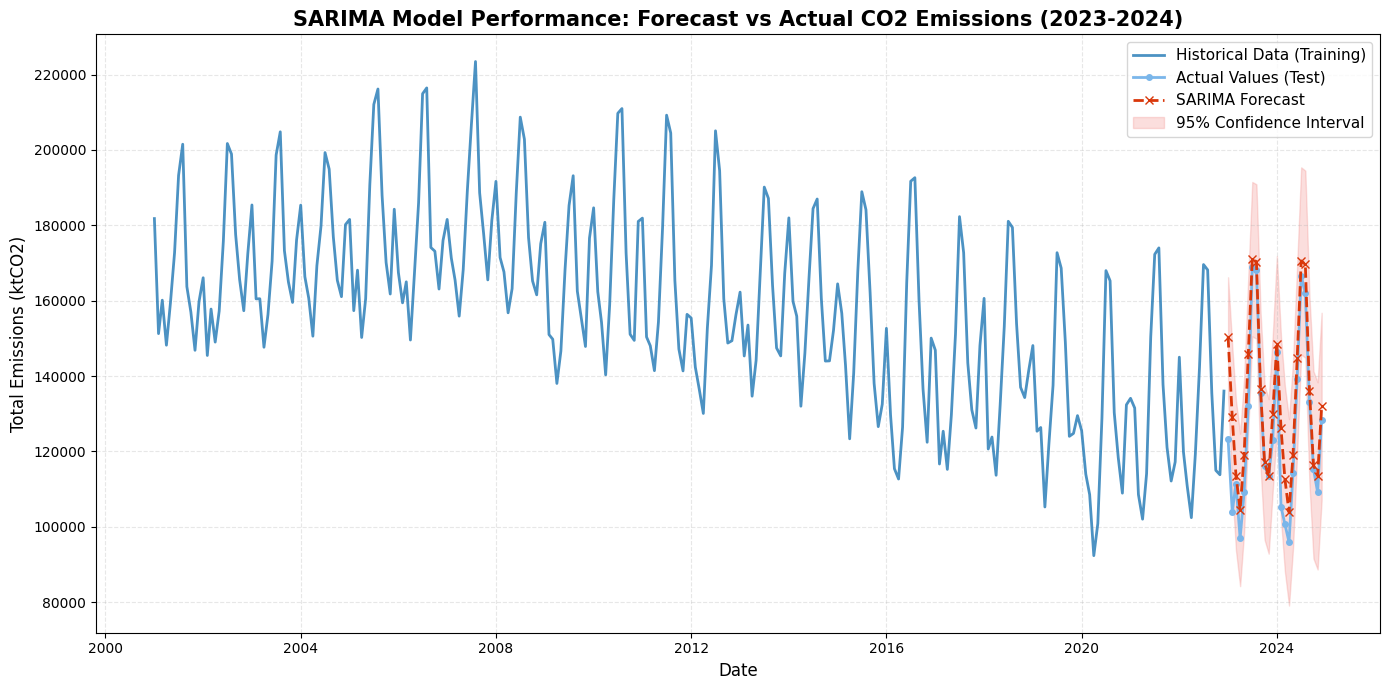

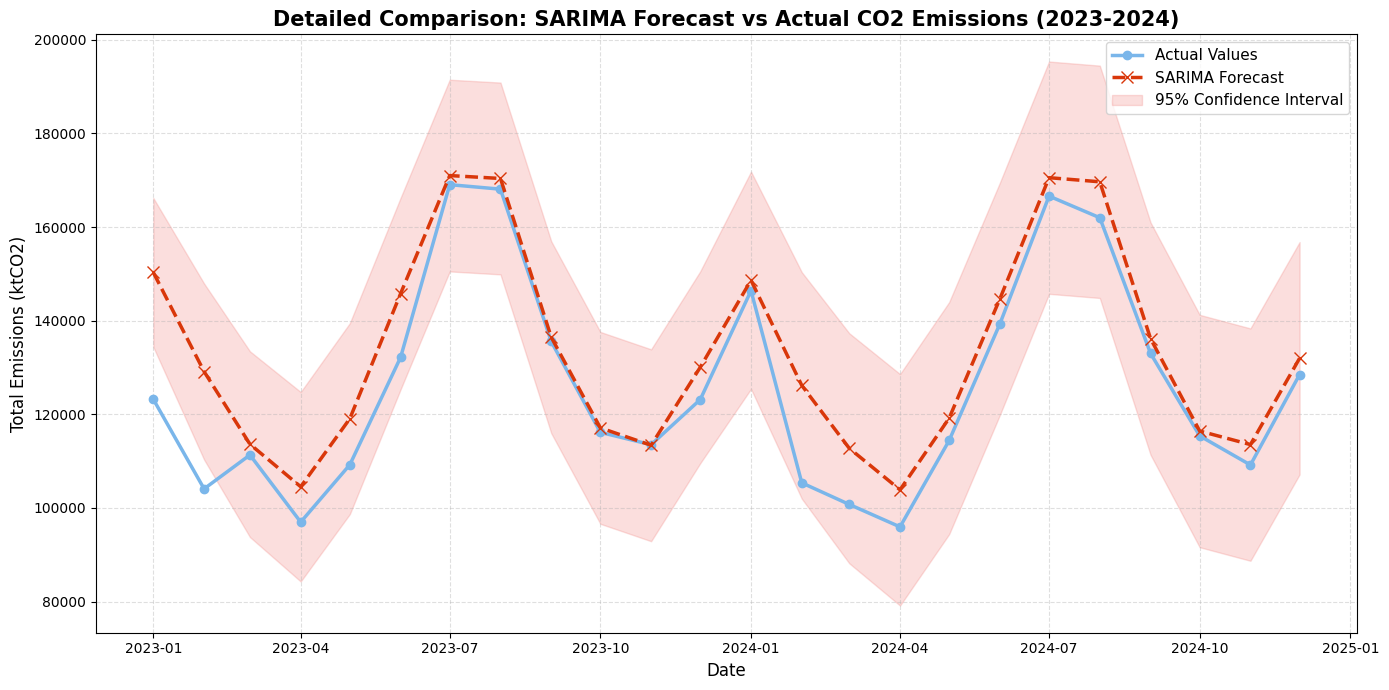


Mean Absolute Percentage Error (MAPE): 6.31%
The model has an average error of 6.31%


In [67]:
train_emissions = ts_emissions.iloc[:-24]
test_emissions = ts_emissions.iloc[-24:]

print(f"Training data: dal {train_emissions.index.min().date()} al {train_emissions.index.max().date()}")
print(f"Test data: dal {test_emissions.index.min().date()} al {test_emissions.index.max().date()}")

# Parametri SARIMA per emissioni
my_order_emissions = (1, 0, 0)              # (p, d, q) - Parte non stagionale
my_seasonal_order_emissions = (1, 1, 0, 12) # (P, D, Q, m) - Parte stagionale (m=12 mesi)

model_emissions = SARIMAX(train_emissions['Value'], 
                          order=my_order_emissions, 
                          seasonal_order=my_seasonal_order_emissions,
                          enforce_stationarity=False,
                          enforce_invertibility=False)

print("Training model...")
model_emissions_fit = model_emissions.fit(disp=False)
print("Model trained successfully!")
print(model_emissions_fit.summary())

forecast_emissions = model_emissions_fit.get_forecast(steps=len(test_emissions))
predicted_emissions = forecast_emissions.predicted_mean
conf_int_emissions = forecast_emissions.conf_int()

plt.figure(figsize=(14, 7))

plt.plot(train_emissions.index, train_emissions['Value'], 
         label='Historical Data (Training)', linewidth=2.0, alpha=0.8) 

plt.plot(test_emissions.index, test_emissions['Value'], 
         label='Actual Values (Test)', 
         color="#7AB6EA", linewidth=2.0, marker='o', markersize=4)

plt.plot(test_emissions.index, predicted_emissions, 
         label='SARIMA Forecast', 
         color="#D9370A", linestyle='--', linewidth=2.0, marker='x', markersize=6)

plt.fill_between(test_emissions.index, 
                 conf_int_emissions.iloc[:, 0], 
                 conf_int_emissions.iloc[:, 1], 
                 color="#F17C78", alpha=0.25, 
                 label='95% Confidence Interval')

plt.title('SARIMA Model Performance: Forecast vs Actual CO2 Emissions (2023-2024)', 
          fontsize=15, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Total Emissions (ktCO2)', fontsize=12)
plt.legend(loc='best', fontsize=11)
plt.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 7))

plt.plot(test_emissions.index, test_emissions['Value'], 
         label='Actual Values', 
         color="#7AB6EA", linewidth=2.5, marker='o', markersize=6)

plt.plot(test_emissions.index, predicted_emissions, 
         label='SARIMA Forecast', 
         color="#D9370A", linestyle='--', linewidth=2.5, marker='x', markersize=8)

plt.fill_between(test_emissions.index, 
                 conf_int_emissions.iloc[:, 0], 
                 conf_int_emissions.iloc[:, 1], 
                 color="#F17C78", alpha=0.25, 
                 label='95% Confidence Interval')

plt.title('Detailed Comparison: SARIMA Forecast vs Actual CO2 Emissions (2023-2024)', 
          fontsize=15, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Total Emissions (ktCO2)', fontsize=12)
plt.legend(fontsize=11, loc='best')
plt.grid(True, alpha=0.4, linestyle='--')
plt.tight_layout()
plt.show()

# Calcolo MAPE
mape_emissions = mean_absolute_percentage_error(test_emissions['Value'], predicted_emissions)
print(f"\nMean Absolute Percentage Error (MAPE): {mape_emissions:.2%}")
print(f"The model has an average error of {mape_emissions:.2%}")


Training model on full dataset...
Model trained successfully!

=== Future Forecasts - CO2 Emissions ===
            Predicted_Value    Lower_Bound    Upper_Bound
Date                                                     
2025-01-01    137858.387636  121397.234099  154319.541173
2025-02-01    105027.989223   85780.936461  124275.041986
2025-03-01    104856.740836   84683.234700  125030.246972
2025-04-01     96393.057025   75889.930357  116896.183692
2025-05-01    112470.380095   91847.563863  133093.196328
2025-06-01    136635.648487  115969.065283  157302.231692
2025-07-01    167562.346123  146879.718250  188244.973995
2025-08-01    164326.843266  143638.328132  185015.358400
2025-09-01    133986.042409  113295.366339  154676.718479
2025-10-01    115677.706045   94986.236700  136369.175389
2025-11-01    110821.569780   90129.809212  131513.330347
2025-12-01    126459.857479  105767.989998  147151.724960
2026-01-01    141109.189774  118019.744983  164198.634566
2026-02-01    105151.88919

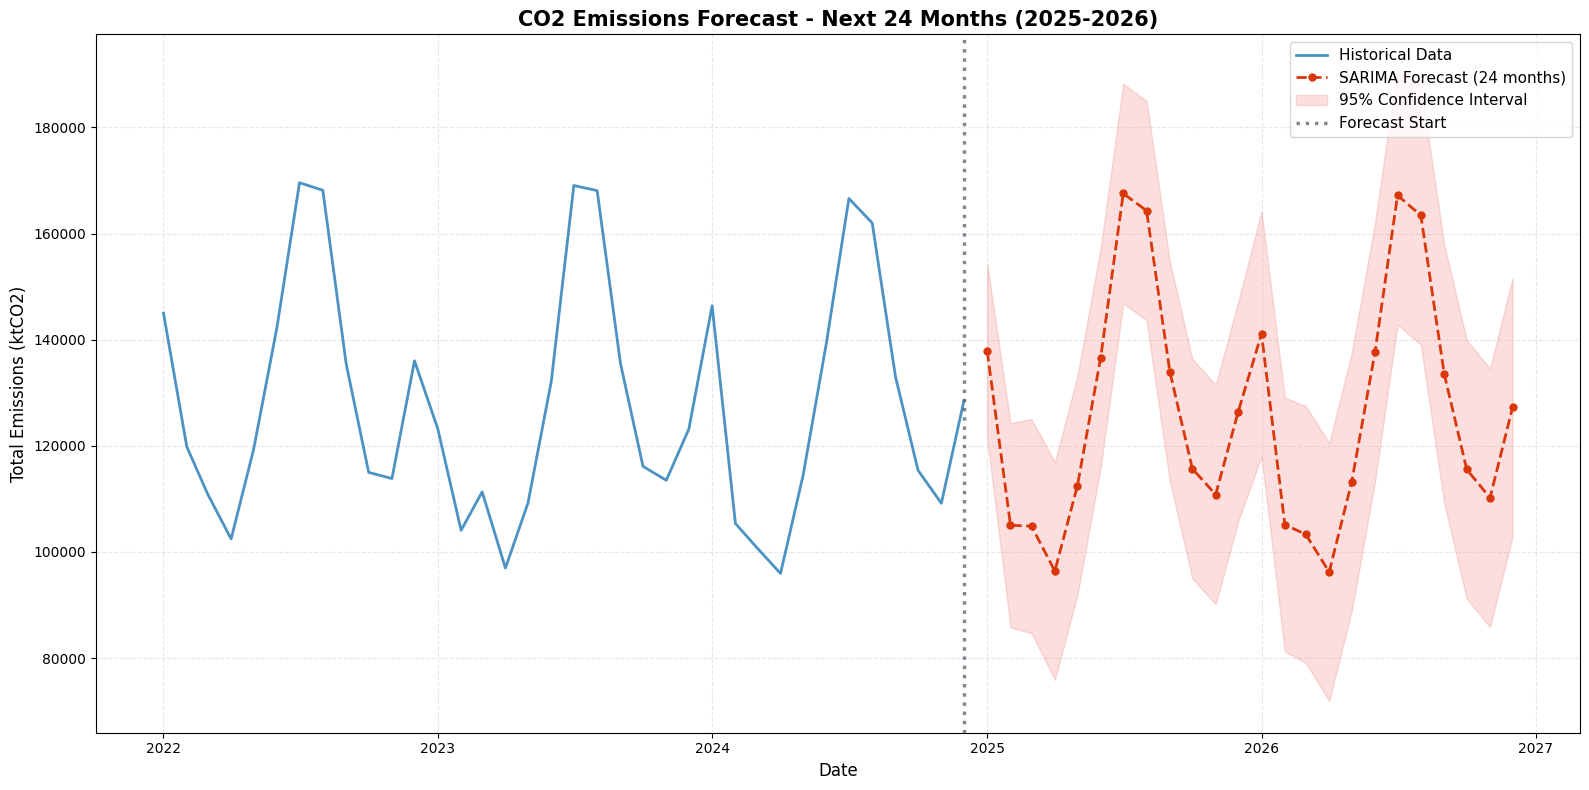

In [68]:
full_emissions = ts_emissions['Value']

my_order_emissions = (1, 0, 0)
my_seasonal_order_emissions = (1, 1, 0, 12)

model_full_emissions = SARIMAX(full_emissions, 
                               order=my_order_emissions, 
                               seasonal_order=my_seasonal_order_emissions,
                               enforce_stationarity=False,
                               enforce_invertibility=False)

print("Training model on full dataset...")
model_full_emissions_fit = model_full_emissions.fit(disp=False)
print("Model trained successfully!")

n_months = 24  # Modify to forecast more or fewer months

forecast_future_emissions = model_full_emissions_fit.get_forecast(steps=n_months)
predicted_future_emissions = forecast_future_emissions.predicted_mean
conf_int_future_emissions = forecast_future_emissions.conf_int()

last_date_emissions = ts_emissions.index[-1]
future_dates_emissions = pd.date_range(start=last_date_emissions + pd.DateOffset(months=1), 
                                       periods=n_months, 
                                       freq='MS')

forecast_emissions_df = pd.DataFrame({
    'Date': future_dates_emissions,
    'Predicted_Value': predicted_future_emissions.values,
    'Lower_Bound': conf_int_future_emissions.iloc[:, 0].values,
    'Upper_Bound': conf_int_future_emissions.iloc[:, 1].values
})
forecast_emissions_df.set_index('Date', inplace=True)

print("\n=== Future Forecasts - CO2 Emissions ===")
print(forecast_emissions_df)

plt.figure(figsize=(16, 8))

historical_emissions = ts_emissions.iloc[-36:]
plt.plot(historical_emissions.index, historical_emissions['Value'], 
         label='Historical Data', linewidth=2.0, alpha=0.8)

plt.plot(future_dates_emissions, predicted_future_emissions, 
         label=f'SARIMA Forecast ({n_months} months)', 
         color="#D9370A", linestyle='--', linewidth=2.0, marker='o', markersize=5)

plt.fill_between(future_dates_emissions, 
                 conf_int_future_emissions.iloc[:, 0], 
                 conf_int_future_emissions.iloc[:, 1], 
                 color="#F17C78", alpha=0.25, 
                 label='95% Confidence Interval')

plt.axvline(x=ts_emissions.index[-1], color="#4A5866", 
            linestyle=':', linewidth=2.5, label='Forecast Start', alpha=0.7)

plt.title(f'CO2 Emissions Forecast - Next {n_months} Months (2025-2026)', 
          fontsize=15, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Total Emissions (ktCO2)', fontsize=12)
plt.legend(loc='best', fontsize=11)
plt.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()


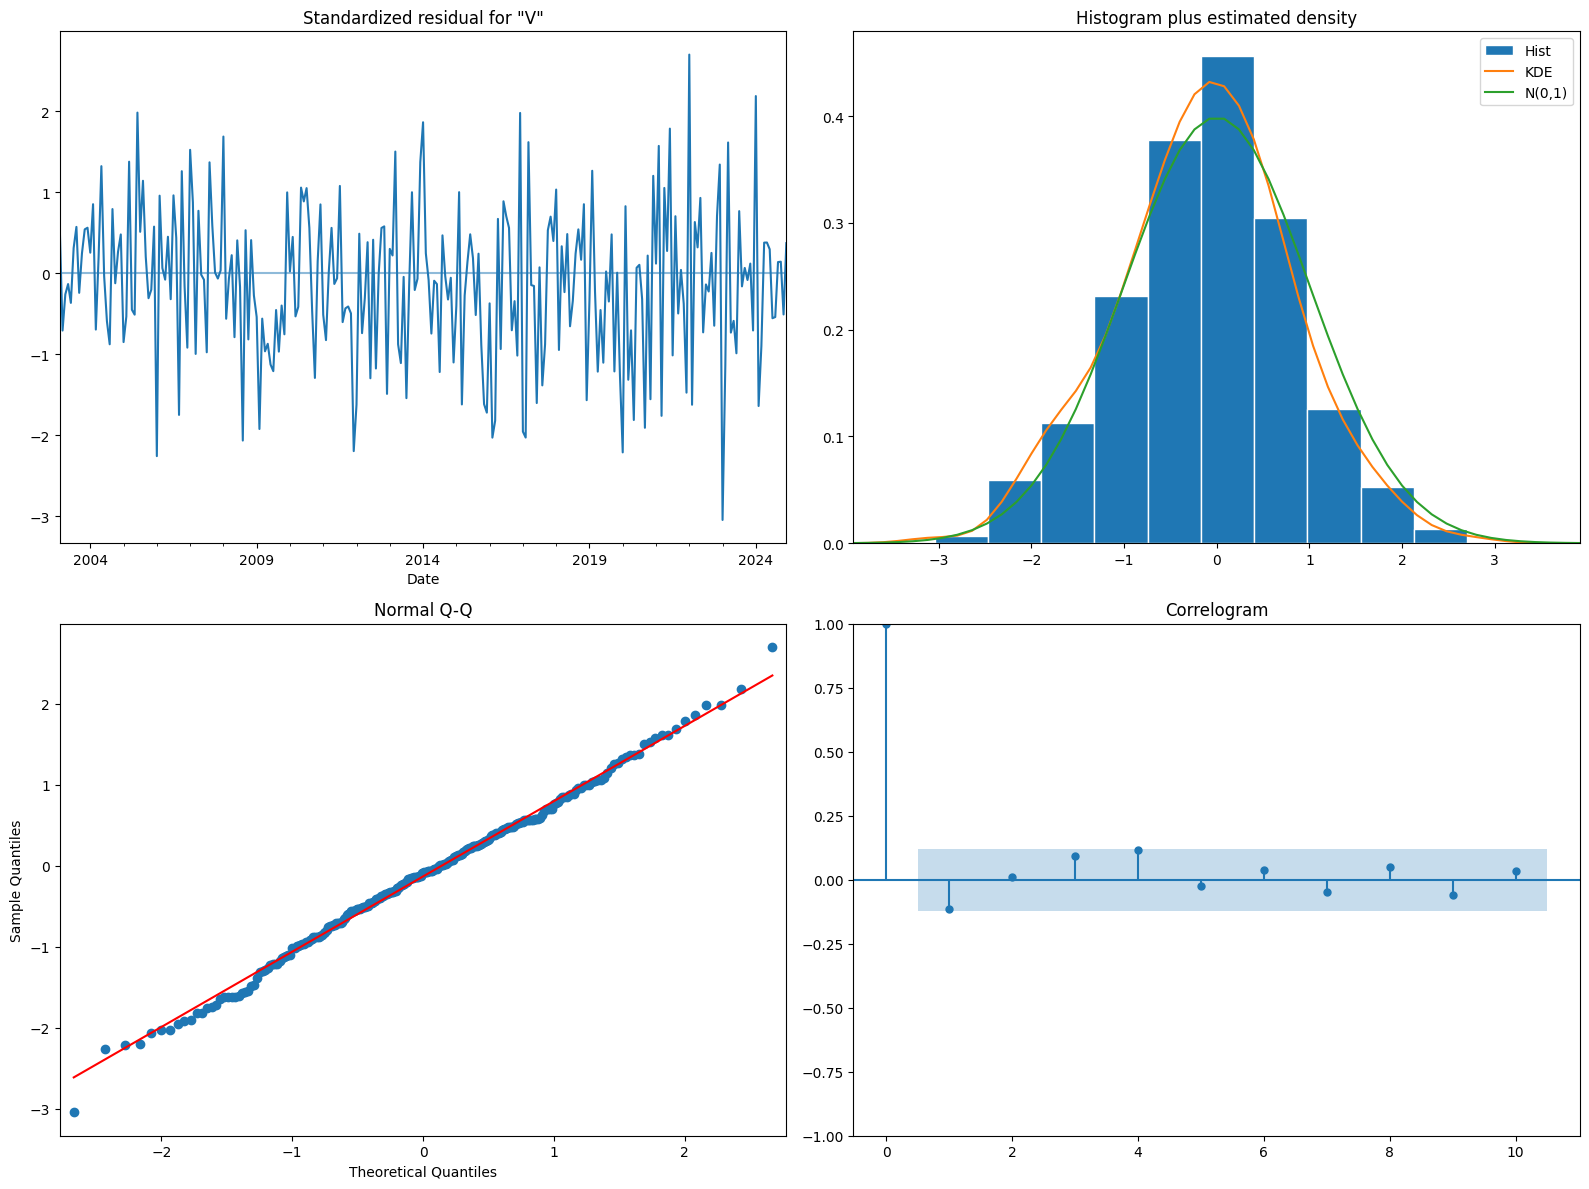

In [36]:
# Diagnostica completa del modello
fig = model_full_emissions_fit.plot_diagnostics(figsize=(16, 12))
plt.tight_layout()
plt.show()

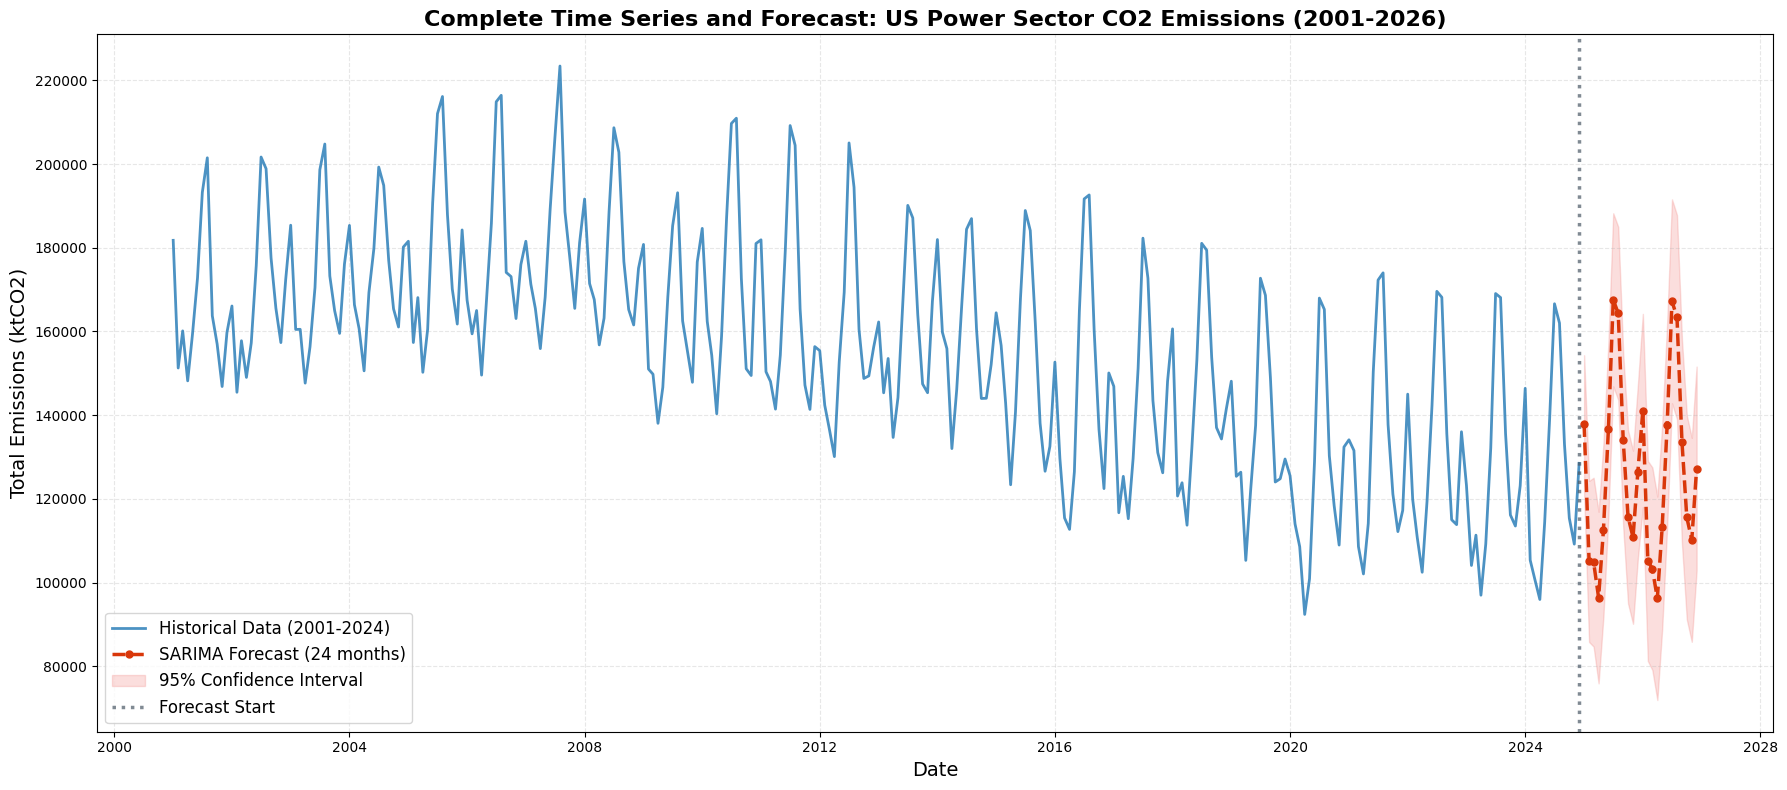

In [69]:
plt.figure(figsize=(18, 8))

plt.plot(ts_emissions.index, ts_emissions['Value'], 
         label='Historical Data (2001-2024)', linewidth=2.0, alpha=0.8)

plt.plot(future_dates_emissions, predicted_future_emissions, 
         label=f'SARIMA Forecast ({n_months} months)', 
         color="#D9370A", linestyle='--', linewidth=2.5, marker='o', markersize=5)

plt.fill_between(future_dates_emissions, 
                 conf_int_future_emissions.iloc[:, 0], 
                 conf_int_future_emissions.iloc[:, 1], 
                 color="#F17C78", alpha=0.25, label='95% Confidence Interval')

plt.axvline(x=ts_emissions.index[-1], color='#4A5866', 
            linestyle=':', linewidth=2.5, label='Forecast Start', alpha=0.7)

plt.title('Complete Time Series and Forecast: US Power Sector CO2 Emissions (2001-2026)', 
          fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=14)
plt.ylabel('Total Emissions (ktCO2)', fontsize=14)
plt.legend(fontsize=12, loc='best')
plt.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()
